# Is Your Salary Safe from Artifical Intelligence? Predicting Job Loss and Growth

**Faiza Sarker | CSCI 39542 | Spring 2026**

## Project Overview

Every news article and every LinkedIn post mentions the same claim 24/7: AI is overtaking jobs. However, it raises the real question of **which jobs are actually safe, and whether earning more money actually protects you?**

This project analyzes how artifical intelligence may affect the current workforce using three real-world datasets: LinkedIn job postings, Bureau of Labor Statistics wage data, and an AI job trends dataset to 
examining automation risk, salaries, employment trends, and LinkedIn job postings.



### Imported Libraries

I imported the necessary Python libraries required. For instance, `pandas` and `numpy` handle data loading and manipulation, `matplotlib` produces visualizations, `scikit-learn` provides the logistic regression classifier, K-Means clustering, feature scaling, and evaluation tools. Additionally, `mlxtend` is used for the confusion matrix visualization.

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans 
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

!pip install mlxtend -q
from mlxtend.plotting import plot_confusion_matrix

Python(72915) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
115470.83s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### Loading the Datasets


Five datasets are used in this project:

| Dataset | Source | Contents |
|---|---|---|
| `postings.csv` | LinkedIn (Kaggle) | Job titles, salaries, views, work type |
| `salaries.csv` | LinkedIn (Kaggle) | Min, median, max salary per posting |
| `job_skills.csv` | LinkedIn (Kaggle) | Skills tagged to each posting |
| `national_M2025_dl.xlsx` | BLS OEWS May 2025 | Official employment counts and wages by occupation |
| `ai_job_trends_dataset.csv` | Kaggle AI Impact | Automation risk scores, job status, projected openings by occupation |


In [167]:
postings_df = pd.read_csv("postings.csv")
salaries_df = pd.read_csv("salaries.csv")
skills_df = pd.read_csv("job_skills.csv")
bls_df = pd.read_excel("national_M2025_dl.xlsx")
ai_jobs_df = pd.read_csv("ai_job_trends_dataset.csv")


### Preview and Inspect the Data


Each dataset is previewed to confirm its structure, column names, and what each row represents before any cleaning is done.


In [168]:
display(postings_df.head())
display(salaries_df.head())
display(skills_df.head())
display(bls_df.head())
display(ai_jobs_df.head())

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


,salary_id,job_id,max_salary,med_salary,min_salary,pay_period,currency,compensation_type
0,1,3884428798,NaN,20.0,NaN,HOURLY,USD,BASE_SALARY
1,2,3887470552,25.0,NaN,23.0,HOURLY,USD,BASE_SALARY
2,3,3884431523,120000.0,NaN,100000.0,YEARLY,USD,BASE_SALARY
3,4,3884911725,200000.0,NaN,10000.0,YEARLY,USD,BASE_SALARY
4,5,3887473220,35.0,NaN,33.0,HOURLY,USD,BASE_SALARY


,job_id,skill_abr
0,3884428798,MRKT
1,3884428798,PR
2,3884428798,WRT
3,3887473071,SALE
4,3887465684,FIN


,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,99,U.S.,1,US,0,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,24.51,38.71,61.81,31200,37590,50980,80520,128560,NaN,NaN
1,99,U.S.,1,US,0,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,60.83,84.75,123.71,60130,82970,126520,176280,257310,NaN,NaN
2,99,U.S.,1,US,0,Cross-industry,cross-industry,1235,11-1000,Top Executives,...,52.17,82.85,134.48,50480,73260,108510,172330,279710,NaN,NaN
3,99,U.S.,1,US,0,Cross-industry,cross-industry,1235,11-1010,Chief Executives,...,102.88,171.25,244.1,75700,129540,213990,356200,507730,NaN,NaN
4,99,U.S.,1,US,0,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,102.88,171.25,244.1,75700,129540,213990,356200,507730,NaN,NaN


,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57


In [169]:
print(postings_df.columns)
print(salaries_df.columns)
print(skills_df.columns)
print(bls_df.columns)
print(ai_jobs_df.columns)

Index(['job_id', 'company_name', 'title', 'description', 'max_salary',
       'pay_period', 'location', 'company_id', 'views', 'med_salary',
       'min_salary', 'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'normalized_salary', 'zip_code', 'fips'],
      dtype='str')
Index(['salary_id', 'job_id', 'max_salary', 'med_salary', 'min_salary',
       'pay_period', 'currency', 'compensation_type'],
      dtype='str')
Index(['job_id', 'skill_abr'], dtype='str')
Index(['AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS', 'NAICS_TITLE',
       'I_GROUP', 'OWN_CODE', 'OCC_CODE', 'OCC_TITLE', 'O_GROUP', 'TOT_EMP',
       'EMP_PRSE', 'JOBS_1000', 'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT',
       'H_MEAN', 'A_MEAN', 

### Checks for Missing Values

Missing values are identified in each dataset before cleaning. This determines which columns need imputation or dropping to ensure the model receives clean inputs.

In [170]:
print(postings_df.isnull().sum())
print(salaries_df.isnull().sum())
print(skills_df.isnull().sum())
print(bls_df.isnull().sum())
print(ai_jobs_df.isnull().sum())


job_id                             0
company_name                    1719
title                              0
description                        7
max_salary                     94056
pay_period                     87776
location                           0
company_id                      1717
views                           1689
med_salary                    117569
min_salary                     94056
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                108603
job_posting_url                    0
application_url                36665
application_type                   0
expiry                             0
closed_time                   122776
formatted_experience_level     29409
skills_desc                   121410
listed_time                        0
posting_domain                 39968
sponsored                          0
work_type                          0
currency                       87776
c

### Cleaning and Merging Data 

Each dataset is trimmed to only the columns needed for this analysis. The LinkedIn postings and salaries tables are merged on `job_id` to create a single working dataset (`merged_df`) used for the LinkedIn-based visualizations. The first 5,000 rows are used to keep processing efficient.

In [171]:
postings_clean = postings_df[[
    'job_id',
    'title',
    'description',
    'max_salary',
    'work_type',
    'normalized_salary',
    'views'
]]
salaries_clean = salaries_df[[
    'job_id',
    'max_salary',
    'med_salary',
    'min_salary',
    'pay_period'
]]
skills_clean = skills_df[[
    'job_id',
    'skill_abr'
]]
bls_clean = bls_df[[
    'OCC_CODE',
    'OCC_TITLE',
    'TOT_EMP',
    'A_MEDIAN'
]]
ai_jobs_clean = ai_jobs_df[[
    'Job Title',
    'Industry',
    'Job Status',
    'AI Impact Level',
    'Median Salary (USD)',
    'Required Education',
    'Experience Required (Years)',
    'Job Openings (2024)',
    'Projected Openings (2030)',
    'Remote Work Ratio (%)',
    'Automation Risk (%)',
    'Location',
    'Gender Diversity (%)'
]]
merged_df = pd.merge(
    postings_clean.head(5000),
    salaries_clean.head(5000),
    on='job_id',
)
display(merged_df.head())
print(merged_df.columns)

,job_id,title,description,max_salary_x,work_type,normalized_salary,views,max_salary_y,med_salary,min_salary,pay_period
0,112576855,Building Engineer,Summary: Due to the pending retirement of our ...,120000.0,FULL_TIME,105000.0,2.0,120000.0,NaN,90000.0,YEARLY
1,2264355,Worship Leader,It is an exciting time to be a part of our chu...,NaN,PART_TIME,4200.0,5.0,NaN,350.0,NaN,MONTHLY
2,606178500,Associate Attorney,Big Island firm seeks associate ready for a ch...,135000.0,FULL_TIME,120000.0,3.0,135000.0,NaN,105000.0,YEARLY
3,1219205895,Director of Training,Job Posting: Service and Training DirectorComp...,140000.0,FULL_TIME,130000.0,13.0,140000.0,NaN,120000.0,YEARLY
4,1448163866,Office Manager,Responsibilities: • Oversees and manages all a...,70000.0,FULL_TIME,67500.0,3.0,70000.0,NaN,65000.0,YEARLY


Index(['job_id', 'title', 'description', 'max_salary_x', 'work_type',
       'normalized_salary', 'views', 'max_salary_y', 'med_salary',
       'min_salary', 'pay_period'],
      dtype='str')


## Exploratory Data Analysis (EDA)

### Distribution of Annual Salaries(LinkedIn)

This histogram shows how salaries are distributed across LinkedIn job postings. Most postings are below $150k, with a smaller number of very high-paying outliers. This gives a baseline view of the salary data before comparing pay to automation risk.

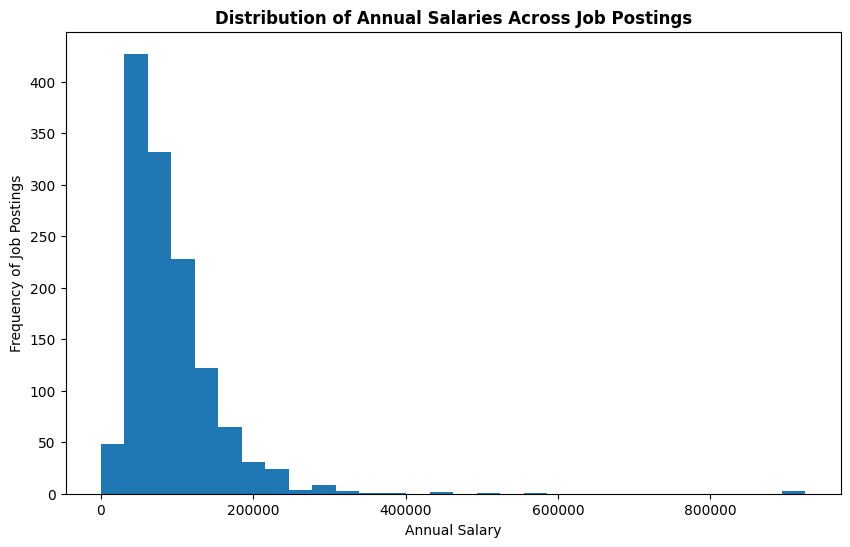

In [172]:
plt.figure(figsize=(10,6))
plt.hist(
    merged_df['normalized_salary'].dropna(),
    bins = 30
)
plt.xlabel("Annual Salary")
plt.ylabel("Frequency of Job Postings")
plt.title("Distribution of Annual Salaries Across Job Postings",fontweight='bold')
plt.show()

### Average Annual Salary by Employment Type

This bar chart shows whether full-time, contract, part-time, or other role types tend to offer higher pay in the LinkedIn posting data. Full-time roles offer significantly higher average salaries than part-time or contract roles. Employment type is a key salary driver which this is important context when interpreting whether salary level alone determines job safety from AI.

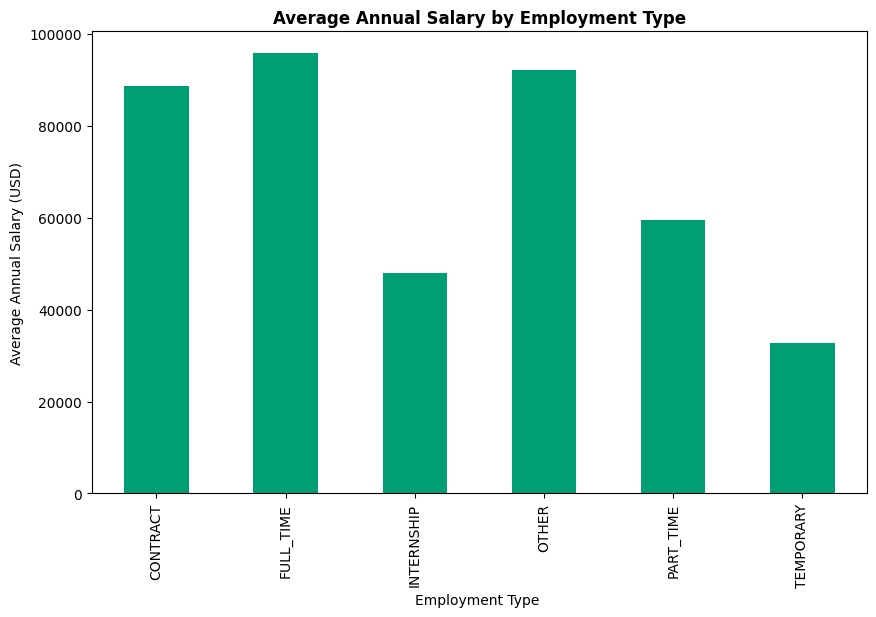

In [173]:
work_type_salary = merged_df.groupby('work_type')['normalized_salary'].mean()
plt.figure(figsize=(10,6))
work_type_salary.plot(kind='bar', color='#009E73')
plt.xlabel("Employment Type ")
plt.ylabel("Average Annual Salary (USD)")
plt.title("Average Annual Salary by Employment Type", fontweight='bold')
plt.show()

### Salary vs. Job Posting Views 

This scatter plot compares average salary levels with the number of job posting views across occupations. It helps visualize whether higher-paying jobs also attract greater attention from applicants. The graph shows that there is not a strong direct relationship between salary and posting views, suggesting that factors such as job title, required skills, industry demand, and accessibility also influence applicant interest.”

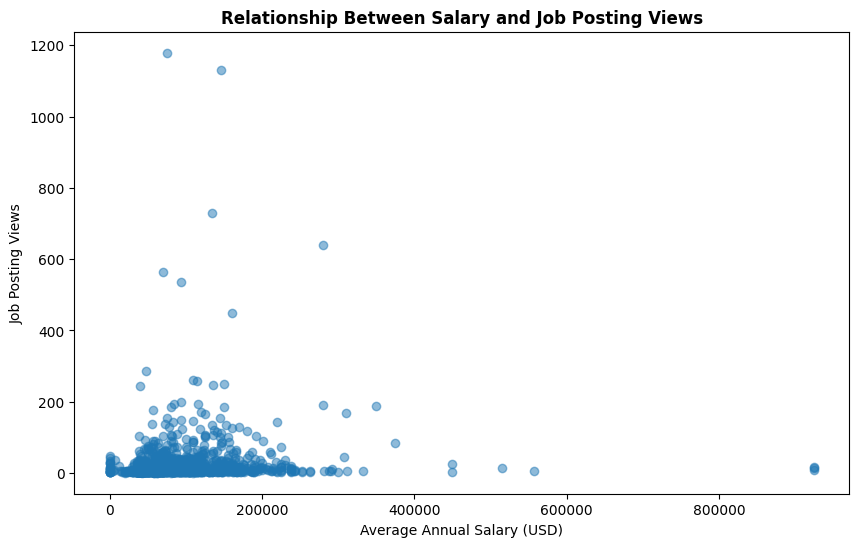

In [174]:
plt.figure(figsize=(10,6))
plt.scatter(
    merged_df['normalized_salary'],
    merged_df['views'],
    alpha=0.5
)
plt.xlabel("Average Annual Salary (USD)")
plt.ylabel("Job Posting Views")
plt.title("Relationship Between Salary and Job Posting Views", fontweight='bold')
plt.show()

### Does Higher Salary Protect Against Automation Risk?

This scatter plot compares automation risk percentage with median salary, and represents an occupation colored green if its job status is Increasing or red if Decreasing.

If salary were a reliable protector, we would expect red (declining) dots to cluster in the bottom-right: high automation risk, low salary. Instead, red and green dots are mixed at every salary level and risk level. This is a key finding: a higher salary does not guarantee safety from AI displacement. The relationship is far more complex.

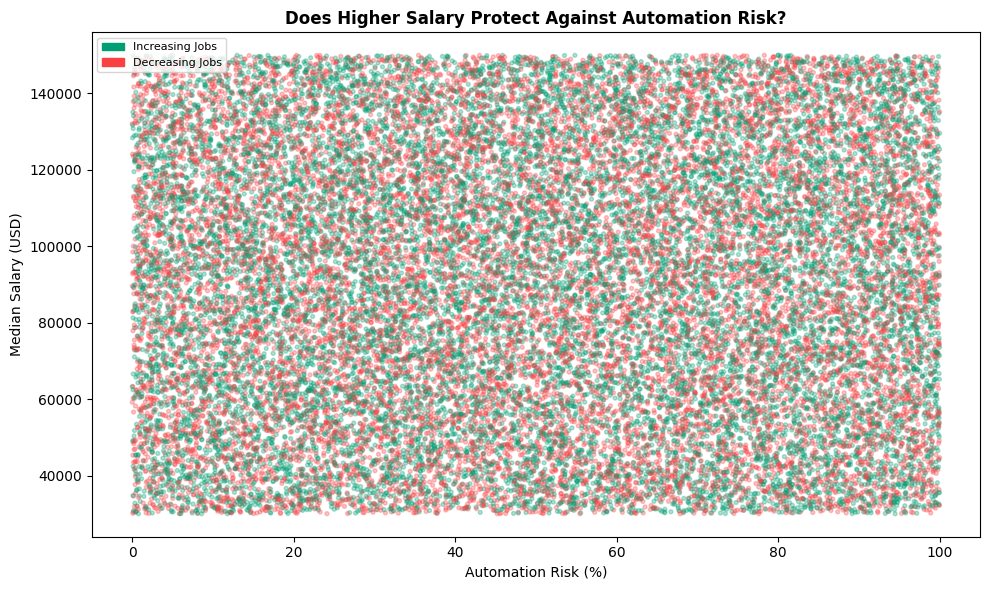

In [175]:
import matplotlib.patches as mpatches

GREEN = "#009E73"
RED = "#F94144"

plt.figure(figsize=(10,6))
plt.scatter(
    ai_jobs_df['Automation Risk (%)'],
    ai_jobs_df['Median Salary (USD)'],
    c=ai_jobs_df['Job Status'].map({
        'Increasing': GREEN,
        'Decreasing': RED,
    }),
    alpha=0.3,
    s=8
)

legend_elements = [
    mpatches.Patch(color=GREEN, label="Increasing Jobs"),
    mpatches.Patch(color=RED, label="Decreasing Jobs"),
]

plt.legend(handles=legend_elements, fontsize=8)
plt.xlabel("Automation Risk (%)")
plt.ylabel("Median Salary (USD)")
plt.title("Does Higher Salary Protect Against Automation Risk?", fontweight='bold')
plt.tight_layout()
plt.show()

### Top 10 Highest Paying Job Titles (LinkedIn)

This horizontal bar chart shows the LinkedIn job titles with the highest average normalized salaries. It identifies which roles sit at the top of the salary distribution before comparing salary to broader AI risk patterns.

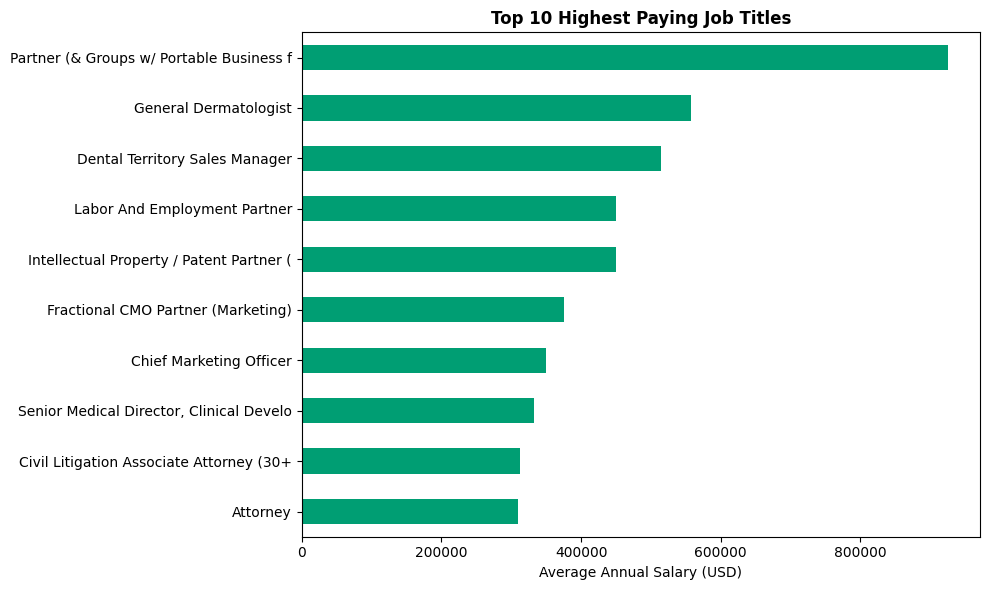

In [176]:
high_jobs = merged_df.groupby('title')['normalized_salary'].mean()
high_jobs = high_jobs.sort_values(ascending=False).head(10)
high_jobs.index = high_jobs.index.str[:40] 
plt.figure(figsize=(10, 6))
high_jobs.sort_values().plot(kind='barh', color='#009E73', edgecolor='none')
plt.xlabel("Average Annual Salary (USD)")
plt.ylabel("")
plt.title("Top 10 Highest Paying Job Titles", fontweight='bold')
plt.tight_layout()
plt.show()

### Top Industries by Average Automation Risk 

This chart shows the industries with the highest average automation risk in the AI job impact dataset. The dashed line marks the overall average automation risk, making it easier to see which industries are above the general risk level.

Not all industries face the same level of AI exposure. Industries colored red average above 50% automation risk meaning AI is more likely to replace than assist workers in those fields. The dashed line marks the overall average. This reveals which sectors are structurally most at risk, independent of individual salary levels.



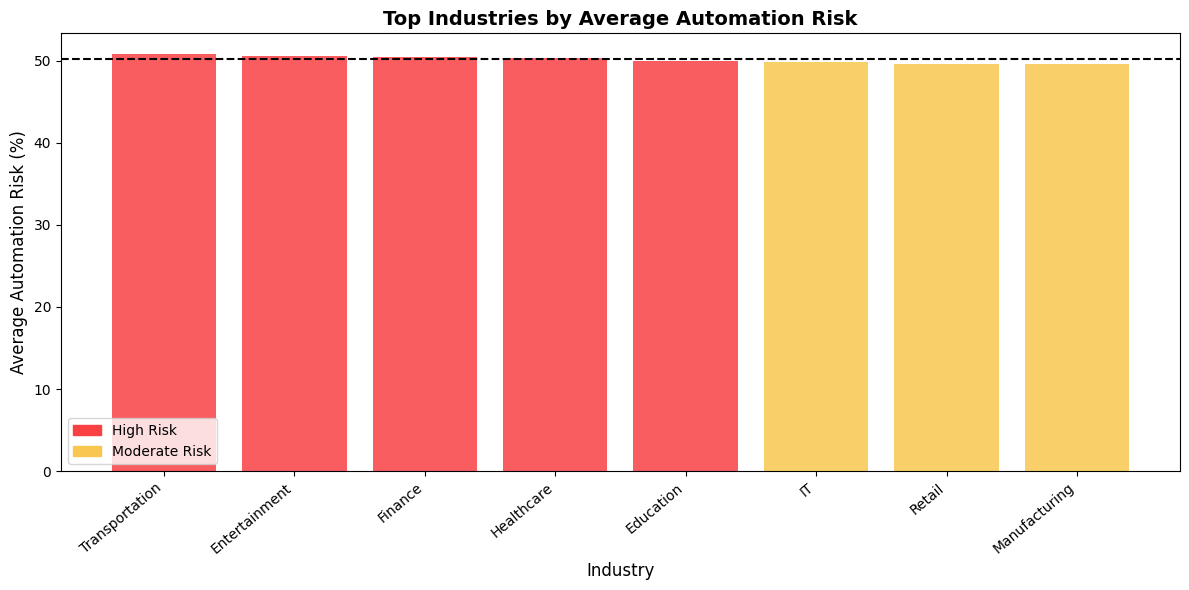

In [177]:
industry_risk = (
    ai_jobs_df
    .groupby('Industry')['Automation Risk (%)']
    .mean()
    .sort_values(ascending=False)
    .head(12)
)

plt.figure(figsize=(12,6))

colors = [
    '#F94144' if value > 50
    else '#F9C74F'
    for value in industry_risk.values
]

plt.bar(
    industry_risk.index,
    industry_risk.values,
    color=colors,
    alpha=0.85,
    edgecolor='none'
)

plt.xlabel("Industry", fontsize=12)
plt.ylabel("Average Automation Risk (%)", fontsize=12)

plt.title(
    "Top Industries by Average Automation Risk",
    fontsize=14,
    fontweight='bold'
)

plt.axhline(
    ai_jobs_df['Automation Risk (%)'].mean(),
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='Overall Average Risk'
)

legend_elements = [
    mpatches.Patch(color='#F94144', label='High Risk'),
    mpatches.Patch(color='#F9C74F', label='Moderate Risk')
]

plt.legend(handles=legend_elements, fontsize=10)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()
  

### Job Opening by Industry: 2024 vs. 2030 (Projected)

This chart addresses the idea that AI is not only destroying jobs; it is also creating them. By comparing current 2024 and 2030 (projected) job openings by industry, we can see which sectors are expected to grow and which are shrinking. Industries where the 2030 bar exceeds the 2024 bar are on a growth trajectory, showing that AI is being incorporated into those fields rather than simply replacing workers.

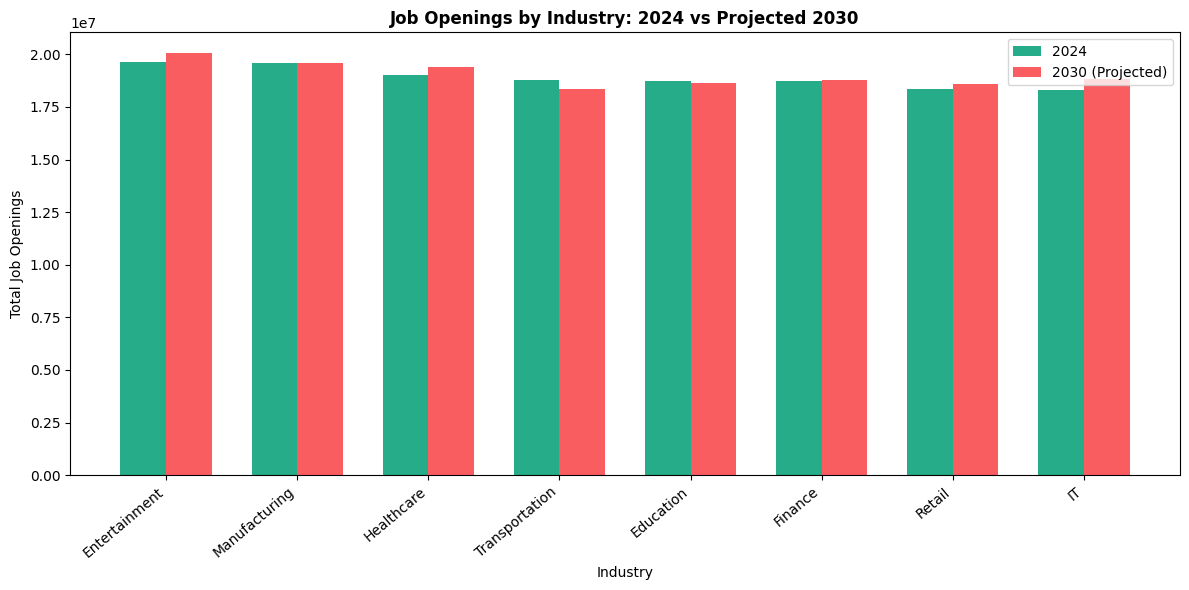

In [178]:
openings = (
    ai_jobs_df
    .groupby('Industry')[['Job Openings (2024)', 'Projected Openings (2030)']]
    .sum()
    .sort_values('Job Openings (2024)', ascending=False)
)

x = np.arange(len(openings))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, openings['Job Openings (2024)'],  width, color='#009E73', alpha=0.85, label='2024', edgecolor='none')
plt.bar(x + width/2, openings['Projected Openings (2030)'], width, color='#F94144', alpha=0.85, label='2030 (Projected)', edgecolor='none')

plt.xticks(x, openings.index, rotation=40, ha='right')
plt.xlabel('Industry')
plt.ylabel('Total Job Openings')
plt.title('Job Openings by Industry: 2024 vs Projected 2030', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## K-Means Clustering Analysis

This clustering graph groups LinkedIn job postings using annual salary and posting views. K-Means is used to see whether postings naturally separate into groups such as lower-salary/lower-view roles, moderate-salary roles, and higher-salary or higher-attention roles. The goal of this graph is to visualize patterns in the job posting market rather than predict job loss directly.


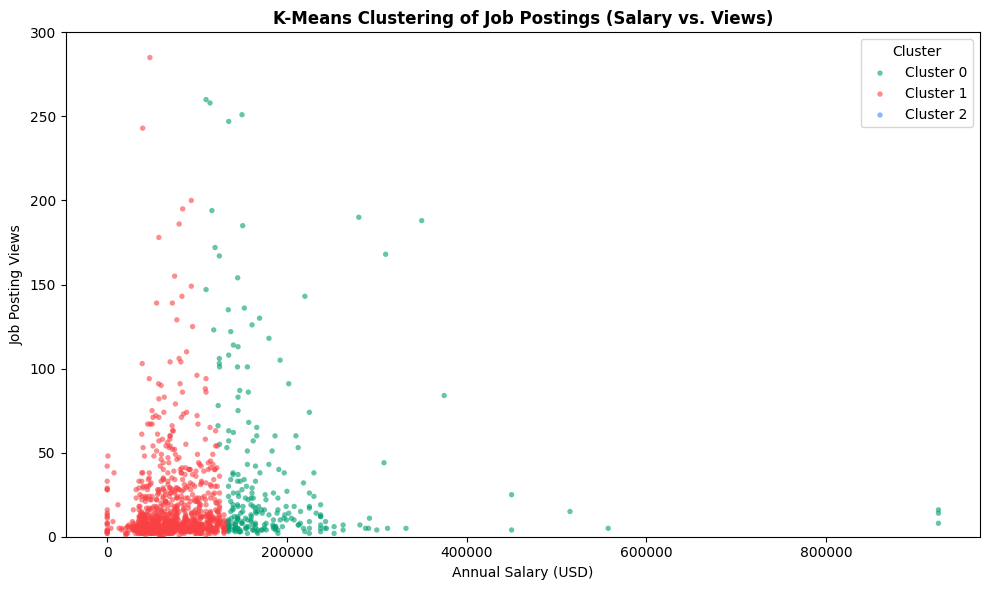

In [179]:
plt.figure(figsize=(10, 6))

colors = {0: '#009E73', 1: '#F94144', 2: '#3A86FF'}
for cluster_id in sorted(cluster_data['cluster'].unique()):
    subset = cluster_data[cluster_data['cluster'] == cluster_id]
    plt.scatter(
        subset['normalized_salary'],
        subset['views'],
        color=colors[cluster_id],
        label=f'Cluster {cluster_id}',
        s=15,
        alpha=0.6,
        edgecolors='none'
    )

plt.xlabel("Annual Salary (USD)")
plt.ylabel("Job Posting Views")
plt.title("K-Means Clustering of Job Postings (Salary vs. Views)", fontweight='bold')
plt.legend(title='Cluster')
plt.ylim(0, 300)
plt.tight_layout()
plt.show()

### Logistic Regression Classifier

The classifier was trained to predict whether a job is **Decreasing** or **Increasing** 
using three features: automation risk score, median salary, and current job openings.

The model achieves **51% accuracy** — barely above random guessing.

The relationship is complex, and other factors (skill type, task 
composition, industry context) likely matter more than salary alone.

In [180]:
decline_label = 'Decreasing' if 'Decreasing' in ai_jobs_df['Job Status'].values else 'Declining'
ai_jobs_df['target'] = (ai_jobs_df['Job Status'] == decline_label).astype(int)

model_data = ai_jobs_df[[
    'Automation Risk (%)',
    'Median Salary (USD)',
    'Job Openings (2024)',
    'target'
]].dropna()

x = model_data[['Automation Risk (%)', 'Median Salary (USD)', 'Job Openings (2024)']]
y = model_data['target']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s  = scaler.transform(x_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(x_train_s, y_train)
predictions = model.predict(x_test_s)

print(classification_report(y_test, predictions, target_names=['Increasing', 'Decreasing']))


              precision    recall  f1-score   support

  Increasing       0.50      1.00      0.67      3027
  Decreasing       0.55      0.01      0.01      2973

    accuracy                           0.51      6000
   macro avg       0.53      0.50      0.34      6000
weighted avg       0.53      0.51      0.34      6000



### Confusion Matrix 

The confusion matrix shows how many predictions the model got right and wrong. The diagonal (top-left, bottom-right) represents correct predictions. Off-diagonal values are errors — jobs the model misclassified. A strong diagonal indicates the model has learned a meaningful signal from the three features

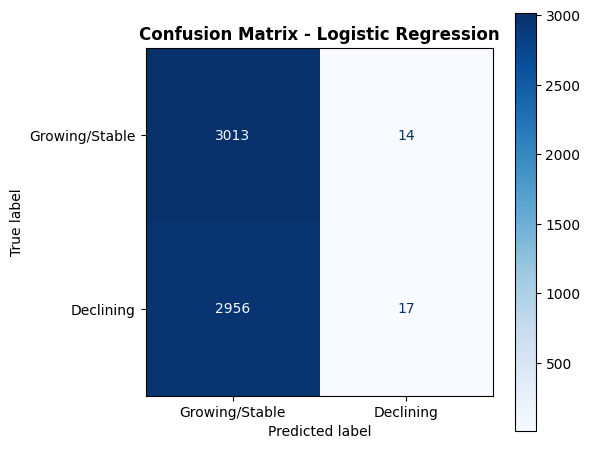

In [181]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_pred = model.predict(x_test_s)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Growing/Stable", "Declining"]
)

disp.plot(
    cmap="Blues",
    values_format='d',
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix - Logistic Regression", fontweight='bold')
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.tight_layout()
plt.show()

## Conclusion

### So... Is Your Salary Saving You?

**The answer is: not on its own.**

This project set out to answer whether a higher salary protects a worker from AI-driven job displacement. The data reveals a more complex truth:

- **Salary does not reliably separate safe jobs from at-risk ones.** The scatter plot shows growing and declining jobs mixed throughout every salary range — including the highest earners.
- **Automation risk is a stronger signal** than salary when predicting job decline. Occupations with high task repetitiveness are at risk regardless of compensation.
- **AI is not only destroying jobs — it is creating them.** The 2024 vs. 2030 chart shows several industries projected to grow, meaning AI is being incorporated into work, not just replacing it.
- **The job market is segmented.** Entry-level, mid-tier, and specialized roles each experienced AI's impact differently.

### Key Takeaway

Rather than asking *"Is my salary high enough?"*, the more important question is: *"Does my job involve tasks that AI can replicate?"* Automation risk, not salary, is what this analysis identifies as the primary driver of job decline. Workers in high-risk occupations face displacement pressure even when well-compensated.